# Stage 2 — Earth interactive network exploration

_Pipeline stage 2 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## From DEM to drainage network — and why the threshold matters

A DEM becomes a **channel network** in three steps: flow routing (`FlowObject`),
thresholding flow accumulation to initiate streams (`StreamObject(threshold)`), and
**Strahler pruning** of the finest tips. The stream-initiation threshold is the single
biggest control on network **drainage density** (Dd = stream length / basin area) —
and Dd is exactly the quantity Stage 4 matches between Earth and Mars.

We characterize one basin's network quantitatively (Strahler structure, Dd-vs-
threshold response), then show how Dd at the three regime thresholds varies across
basins — the spread that the regimes are designed to bracket.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
from channel_heads.dd_calibration import collect_basin_metrics_for_dem
from channel_heads.basin_config import get_basin_config
from channel_heads.regimes import REGIMES
BASIN = 'inyo'
cfg = get_basin_config(BASIN); lat, z_th = cfg['lat'], cfg['z_th']
m = max(collect_basin_metrics_for_dem(dem_path=EXAMPLE_DEMS[BASIN], basin_name=BASIN,
        thresholds_km2=[0.10], z_th=z_th, lat_deg=lat), key=lambda x: x.n_stream_nodes)
print(f'{BASIN} @ 0.10 km2:  Dd={m.dd_true_km_km2:.3f} km/km2 | length={m.stream_length_km:.0f} km '
      f'| area={m.basin_area_km2:.0f} km2 | stream nodes={m.n_stream_nodes}')

inyo @ 0.10 km2:  Dd=1.873 km/km2 | length=44 km | area=23 km2 | stream nodes=460


### 1 · Strahler-order structure

In [3]:
dist = getattr(m, 'strahler_distribution', None) or {}
if dist:
    orders = sorted(dist); fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(orders, [dist[o] for o in orders], color='steelblue', edgecolor='white')
    ax.set_xlabel('Strahler order'); ax.set_ylabel('node count')
    ax.set_title(f'{BASIN}: Strahler distribution @ 0.10 km2'); ax.set_xticks(orders); plt.show()
    print('Strahler-1 (finest tips) are the most numerous and the first removed by pruning.')

### 2 · Drainage density vs stream-initiation threshold

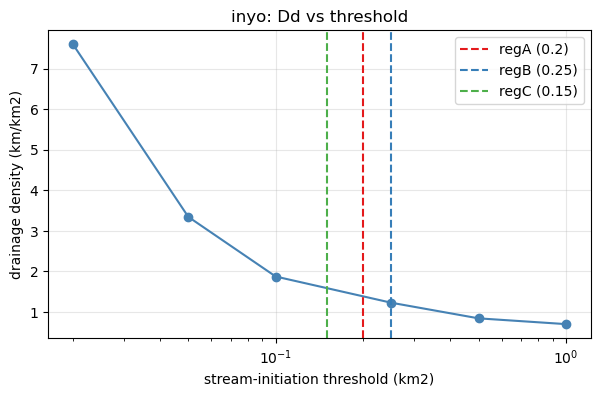

,threshold_km2,dd,nodes
0,0.02,7.601944,1820
1,0.05,3.343187,813
2,0.10,1.873024,460
3,0.25,1.227322,304
4,0.50,0.842003,210
5,1.00,0.699796,156


In [4]:
SWEEP = [0.02, 0.05, 0.10, 0.25, 0.5, 1.0]
sweep = collect_basin_metrics_for_dem(dem_path=EXAMPLE_DEMS[BASIN], basin_name=BASIN,
        thresholds_km2=SWEEP, z_th=z_th, lat_deg=lat)
best = {}
for x in sweep:
    if x.threshold_km2 not in best or x.n_stream_nodes > best[x.threshold_km2].n_stream_nodes:
        best[x.threshold_km2] = x
sw = pd.DataFrame([{'threshold_km2': t, 'dd': best[t].dd_true_km_km2,
                    'nodes': best[t].n_stream_nodes} for t in SWEEP if t in best])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sw.threshold_km2, sw.dd, 'o-', color='steelblue')
ax.set_xscale('log'); ax.set_xlabel('stream-initiation threshold (km2)')
ax.set_ylabel('drainage density (km/km2)'); ax.set_title(f'{BASIN}: Dd vs threshold')
for nm, r in REGIMES.items():
    ax.axvline(r.threshold_km2, ls='--', color=RC[nm], label=f'{nm} ({r.threshold_km2})')
ax.legend(); ax.grid(alpha=0.3); plt.show()
sw

Lower threshold → denser network (more 1st-order tips survive) → higher Dd.

### 3 · How Dd at the regime thresholds varies across basins

regime,regA,regB,regC
basin,,,
calnalpine,1.388,1.266,1.545
inyo,1.337,1.227,1.509
panamint,1.923,1.738,2.203
troodos,1.428,1.306,1.655


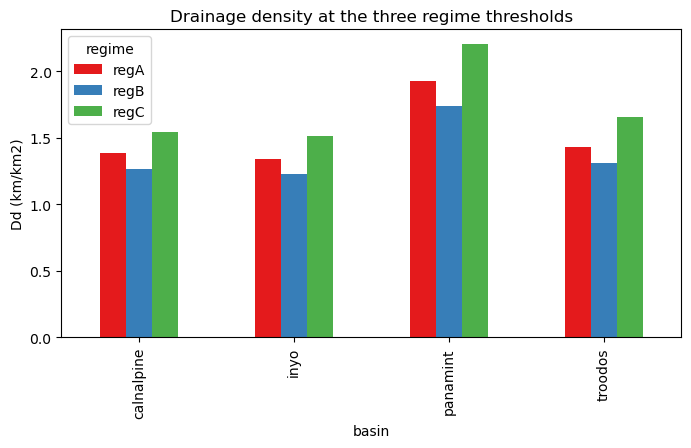

In [5]:
# A few representative basins (kept small for headless runtime).
SUBSET = ['inyo', 'troodos', 'calnalpine', 'panamint']
rows = []
for b in SUBSET:
    if b not in EXAMPLE_DEMS: continue
    c = get_basin_config(b)
    for nm, r in REGIMES.items():
        res = collect_basin_metrics_for_dem(dem_path=EXAMPLE_DEMS[b], basin_name=b,
              thresholds_km2=[r.threshold_km2], z_th=c['z_th'], lat_deg=c['lat'])
        if res:
            mm = max(res, key=lambda x: x.n_stream_nodes)
            rows.append({'basin': b, 'regime': nm, 'dd': round(mm.dd_true_km_km2, 3)})
ddm = pd.DataFrame(rows).pivot(index='basin', columns='regime', values='dd')
display(ddm)
ax = ddm.plot(kind='bar', color=[RC[c] for c in ddm.columns], figsize=(8, 4))
ax.set_ylabel('Dd (km/km2)'); ax.set_title('Drainage density at the three regime thresholds'); plt.show()

**Takeaway.** Within a basin, regA (0.05 km²) is densest and regB (0.25 km²)
sparsest, with regC between — and the absolute Dd differs markedly across basins.
Stage 4 picks these thresholds so the resulting Earth Dd *brackets* the martian Dd,
making the Earth→Mars comparison fair rather than an artifact of mismatched
complexity.